#1. Preparação dos dados

##Importação e unificação

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os

# 1. Configurações base
base_url = "https://github.com/Projeto-Aplicado-2-Mackenzie/analise-sentimento/blob/main/dataset/"
lista_df = []

print("Iniciando o download e a unificação dos 6 arquivos...")

# 2. Loop de 1 a 6
for i in range(1, 7):
    nome_arquivo = f"arquivo_parte_{i}.csv"
    url_download = f"{base_url}{nome_arquivo}?raw=true"

    # Baixa o arquivo silenciosamente (-q) e sobrescreve se já existir (-O)
    !wget -q -O {nome_arquivo} "{url_download}"

    tamanho = os.path.getsize(nome_arquivo)

    if tamanho > 100:
        try:
            # Lendo com engine 'python' para detectar automaticamente se o separador é ',' ou ';'
            df_temp = pd.read_csv(nome_arquivo, sep=None, engine='python', encoding='utf-8')
            lista_df.append(df_temp)
            print(f"{nome_arquivo} lido com sucesso! ({len(df_temp)} linhas)")
        except Exception as e:
            print(f"Erro ao processar {nome_arquivo}: {e}")
    else:
        print(f"{nome_arquivo} ignorado (está vazio ou com erro no GitHub - {tamanho} bytes)")

# 3. Concatenando todos os arquivos em um único DataFrame
if lista_df:
    df_final = pd.concat(lista_df, ignore_index=True)
    print("\n" + "="*30)
    print(f"PROCESSO CONCLUÍDO!")
    print(f"Total de linhas consolidadas: {len(df_final)}")
    print("="*30)
else:
    print("\nErro: Nenhum dado válido foi encontrado para criar o DataFrame.")

Iniciando o download e a unificação dos 6 arquivos...
arquivo_parte_1.csv lido com sucesso! (7696 linhas)
arquivo_parte_2.csv lido com sucesso! (7696 linhas)
arquivo_parte_3.csv lido com sucesso! (7696 linhas)
arquivo_parte_4.csv lido com sucesso! (7695 linhas)
arquivo_parte_5.csv lido com sucesso! (7695 linhas)
arquivo_parte_6.csv lido com sucesso! (7695 linhas)

PROCESSO CONCLUÍDO!
Total de linhas consolidadas: 46173


##Prévia

In [112]:
# Exibe as primeiras linhas do resultado final
display(df_final.head())

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
3,3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
4,4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


##Limpeza de colunas não utilizadas

In [113]:
# Remove colunas que não serão trabalhadas
df_final = df_final.drop(columns=['Unnamed: 0', 'Description', 'emotion'], errors='ignore')

# Exibe para conferir
display(df_final.head())

,Ratings,Reviews,movie_name,Resenhas,genres
0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']"
1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']"
2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']"
3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']"
4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']"


##Limpeza de linhas duplicadas

In [114]:
#Contando em quantas linhas a coluna 'Resenha' está duplicada:
duplicadas = df_final['Resenhas'].duplicated().sum()
print(duplicadas)

26857


In [115]:
df_final = df_final.drop_duplicates(subset=['Resenhas'])
df_final.reset_index(drop=True, inplace=True)
df_final.info()

#O dataset a ser trabalhado tem 19316 Linhas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19316 entries, 0 to 19315
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ratings     19316 non-null  float64
 1   Reviews     19316 non-null  object 
 2   movie_name  19316 non-null  object 
 3   Resenhas    19316 non-null  object 
 4   genres      19316 non-null  object 
dtypes: float64(1), object(4)
memory usage: 754.7+ KB


#2. Visualizações gerais

## Visualização de volume por gênero  

###Visão geral

/tmp/ipykernel_12556/2707629234.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


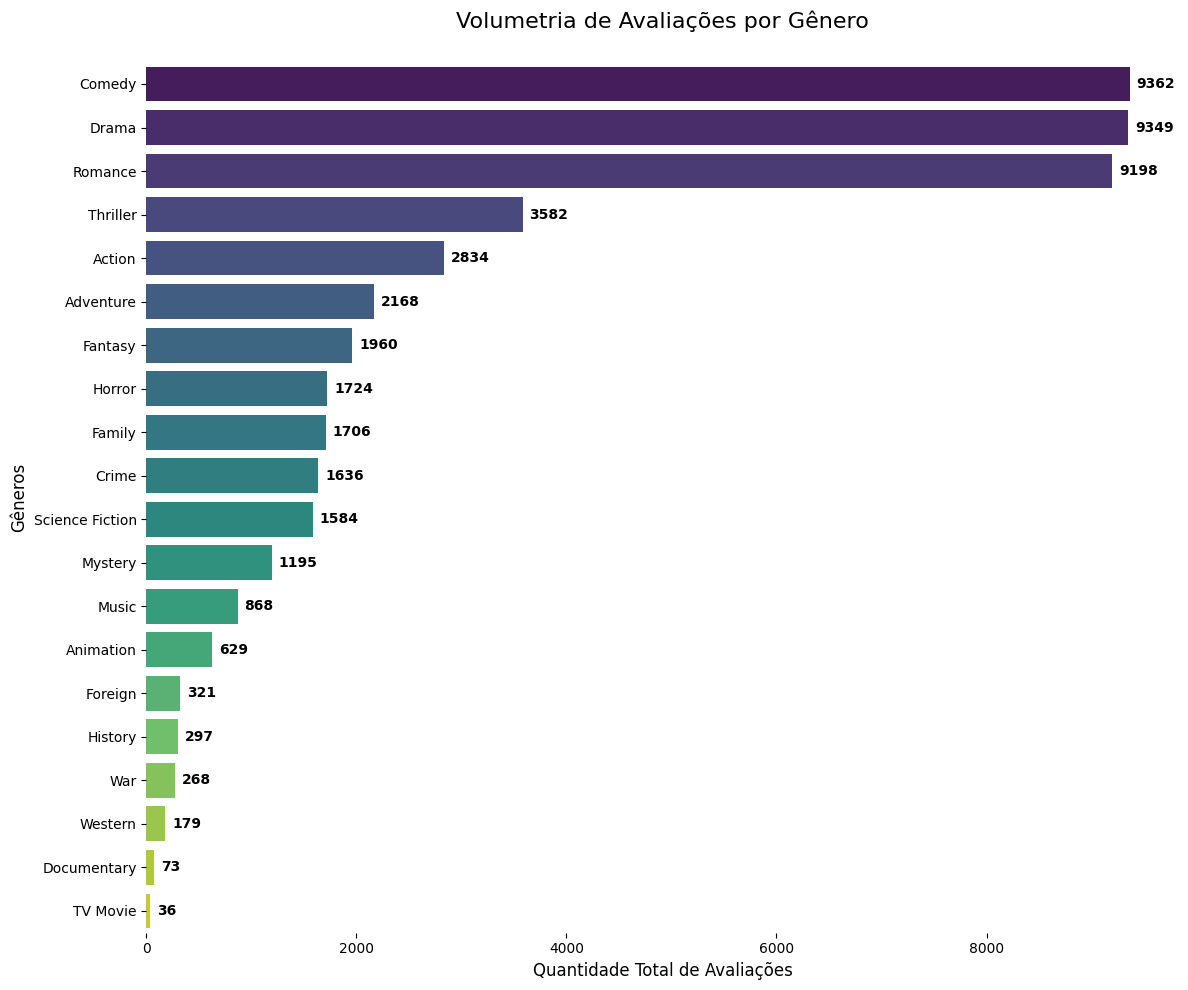

In [116]:
# 1. Preparação dos dados
df_final['genres'] = df_final['genres'].apply(ast.literal_eval)
generos_explodidos = df_final.explode('genres').reset_index(drop=True)


# 2. Configuração do tamanho da figura
plt.figure(figsize=(12, 10)) # Aumentei um pouco a altura para os rótulos não ficarem apertados

# 3. Criação do gráfico
ax = sns.countplot(
    y='genres',
    data=generos_explodidos,
    order=generos_explodidos['genres'].value_counts().index,
    palette='viridis'
)

# 4. APLICANDO O RÓTULO EM TODAS AS BARRAS (LOOP)
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, fontweight='bold')

# 5. Ajustes finais
plt.title("Volumetria de Avaliações por Gênero", fontsize=16, pad=25)
plt.xlabel("Quantidade Total de Avaliações", fontsize=12)
plt.ylabel("Gêneros", fontsize=12)

# Deixa as bordas mais limpas
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

###Visão percentual

/tmp/ipykernel_12556/4115293187.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


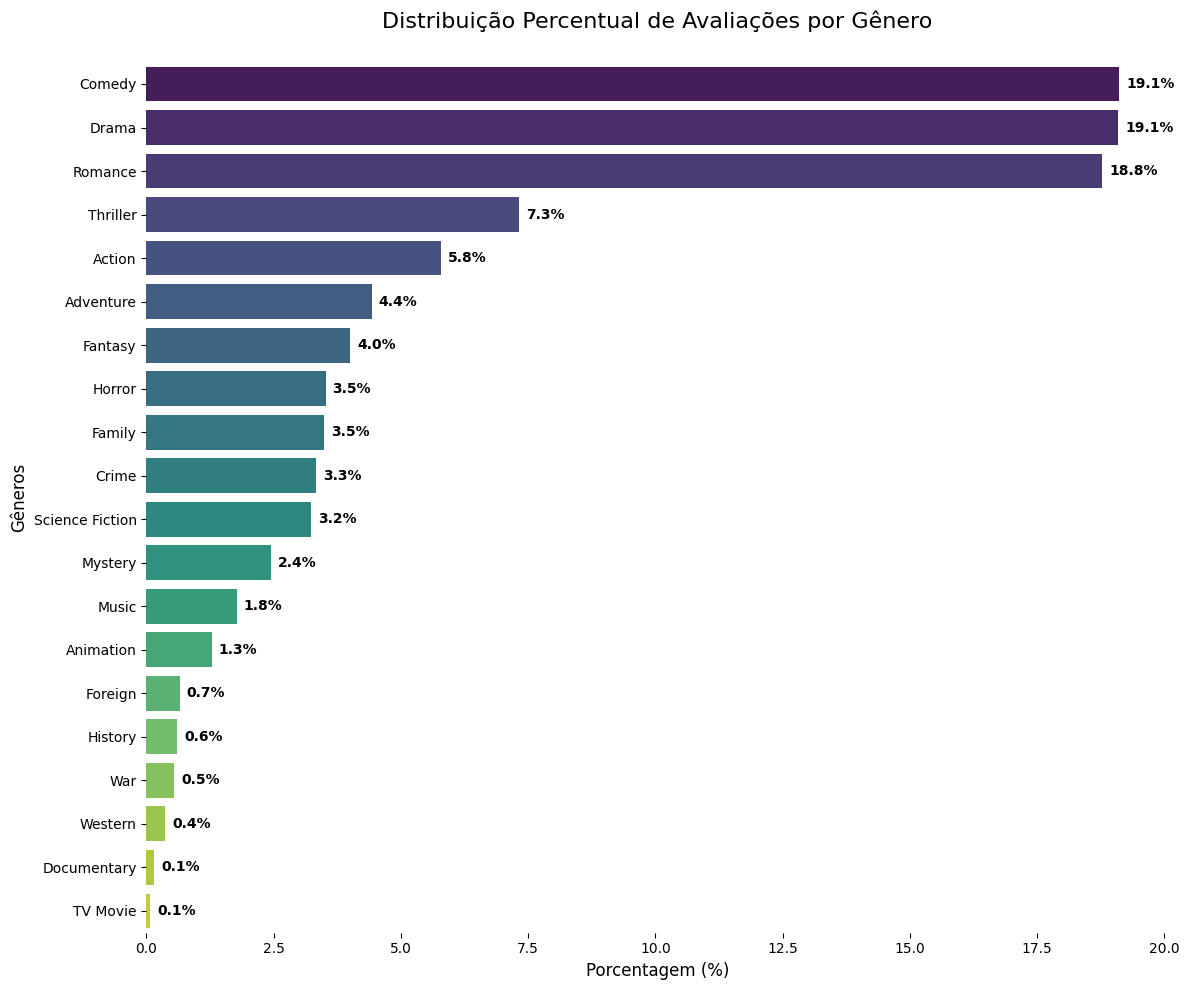

In [117]:
# 1. Calculamos a frequência relativa (normalize=True) e multiplicamos por 100
df_percent = (generos_explodidos['genres'].value_counts(normalize=True) * 100).reset_index()
df_percent.columns = ['genres', 'percentage']

# 2. Configuração do gráfico
plt.figure(figsize=(12, 10))

# 3. Criação do gráfico de barras
ax = sns.barplot(
    x='percentage',
    y='genres',
    data=df_percent,
    palette='viridis'
)

# 4. ADICIONANDO OS RÓTULOS PERCENTUAIS EM TODAS AS BARRAS
# O parâmetro fmt='%.1f%%' formata o número com uma casa decimal e o símbolo %
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

# 5. Ajustes de títulos e eixos
plt.title("Distribuição Percentual de Avaliações por Gênero", fontsize=16, pad=25)
plt.xlabel("Porcentagem (%)", fontsize=12)
plt.ylabel("Gêneros", fontsize=12)

# Limpeza visual
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

###Word Cloud por nota de avaliação

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


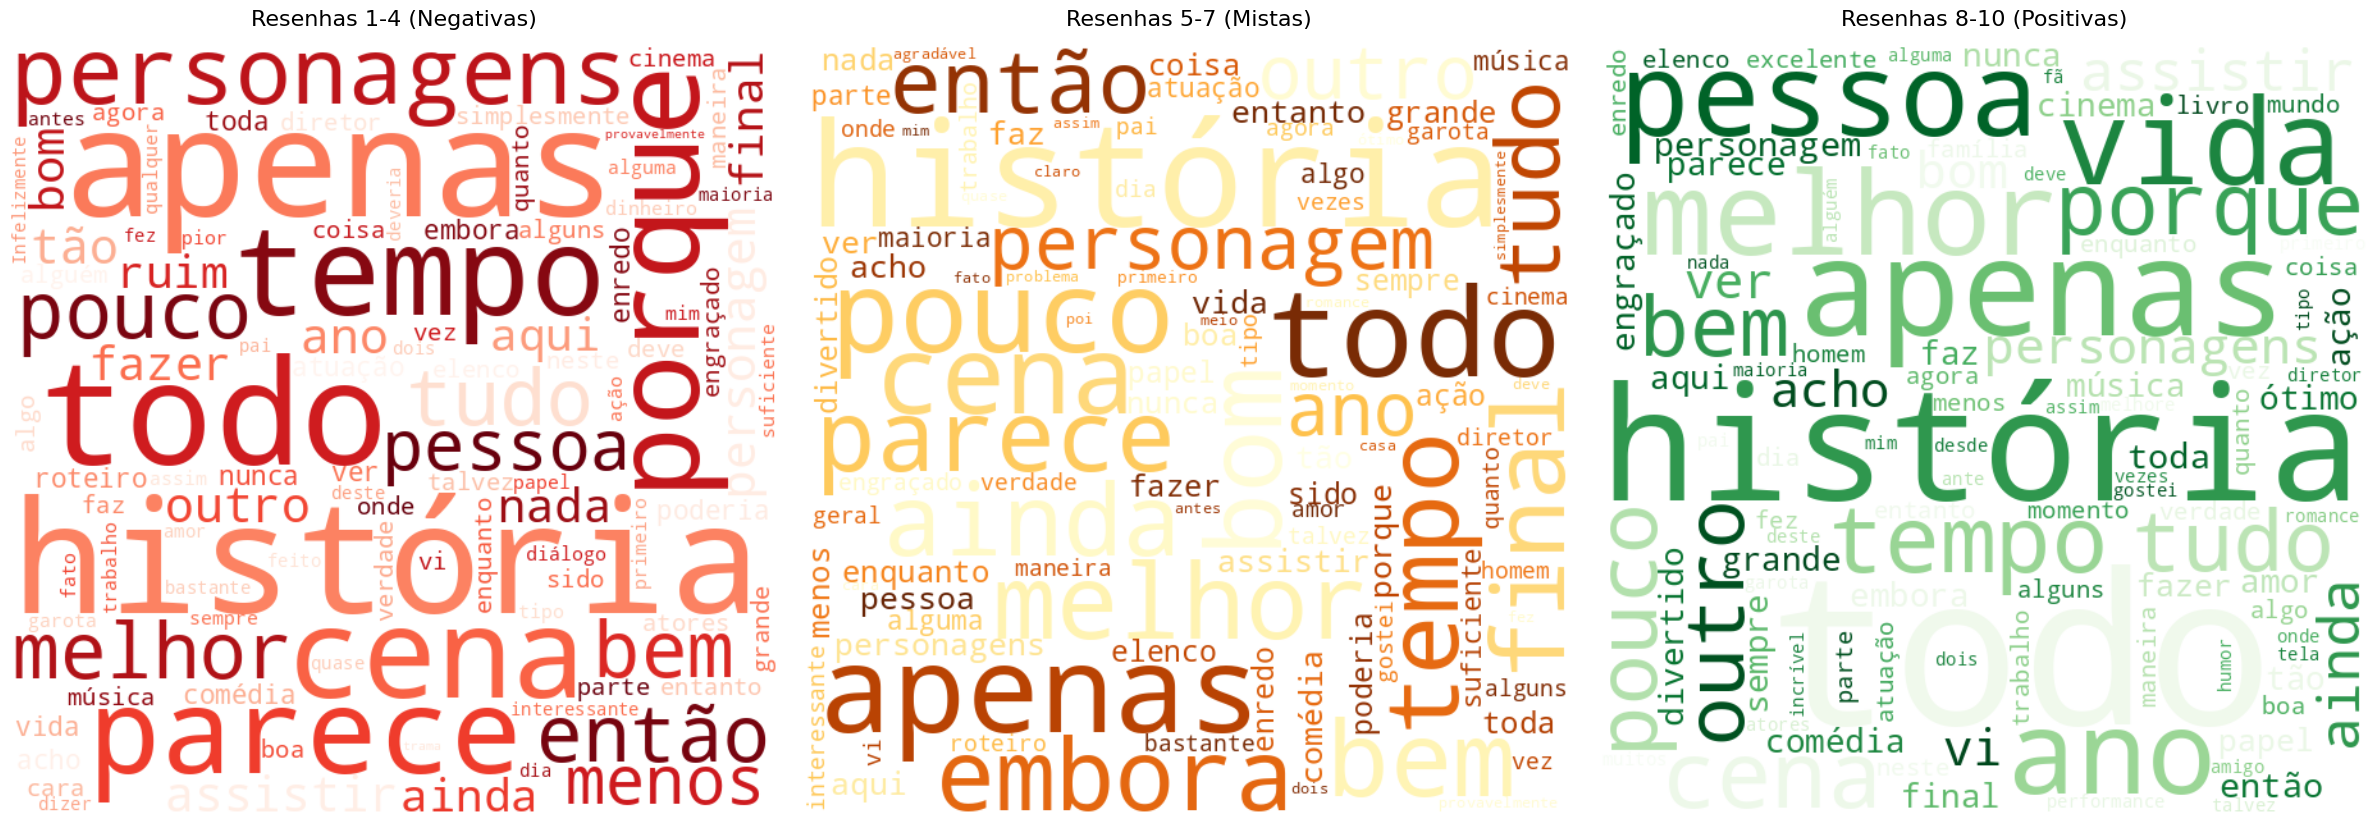

In [118]:
import nltk
from wordcloud import WordCloud

# 1. Baixar as stopwords em português se ainda não tiver
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words_pt = stopwords.words('portuguese')

# Adicionando palavras comuns de cinema que podem poluir a nuvem (opcional)
stop_words_pt.extend(['filme', 'filmes', 'sobre', 'ter', 'ser', 'pode', 'realmente'])

# 2. Definindo a coluna de texto (Resenhas em Português)
coluna_pt = 'Resenhas'

# 3. Preparando os textos por faixa
texto_baixo_pt  = " ".join(df_final[(df_final['Ratings'] >= 1) & (df_final['Ratings'] <= 4)][coluna_pt].astype(str))
texto_medio_pt  = " ".join(df_final[(df_final['Ratings'] >= 5) & (df_final['Ratings'] <= 7)][coluna_pt].astype(str))
texto_alto_pt   = " ".join(df_final[(df_final['Ratings'] >= 8) & (df_final['Ratings'] <= 10)][coluna_pt].astype(str))

# 4. Gerando as nuvens
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

# Função auxiliar para criar a nuvem PT
def criar_nuvem_pt(texto, titulo, cor, eixo):
    wc = WordCloud(
        width=600, height=600,
        background_color='white',
        colormap=cor,
        stopwords=stop_words_pt, # Aplicando as stopwords em português
        max_words=100
    ).generate(texto)
    eixo.imshow(wc, interpolation='bilinear')
    eixo.set_title(titulo, fontsize=16, pad=15)
    eixo.axis('off')

# Plotando as 3
criar_nuvem_pt(texto_baixo_pt, "Resenhas 1-4 (Negativas)", 'Reds', ax1)
criar_nuvem_pt(texto_medio_pt, "Resenhas 5-7 (Mistas)", 'YlOrBr', ax2)
criar_nuvem_pt(texto_alto_pt, "Resenhas 8-10 (Positivas)", 'Greens', ax3)

plt.tight_layout()
plt.show()

###3 DFs com as palavras mais utilizadas

In [119]:
import pandas as pd
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# 1. Configuração das Stopwords em Português
try:
    nltk.download('stopwords')
    stop_words_pt = set(stopwords.words('portuguese'))
except:
    # Caso esteja sem internet, uma lista básica de fallback
    stop_words_pt = {'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito', 'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre', 'depois', 'sem', 'mesmo', 'aos', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram', 'essa', 'num', 'nem', 'suas', 'meu', 'minha', 'numa', 'pelos', 'elas', 'havia', 'seja', 'qual', 'será', 'nós', 'tenho', 'lhe', 'deles', 'essas', 'esses', 'pelas', 'este', 'fosse', 'dele', 'tu', 'te', 'vocês', 'vos', 'lhes', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'nosso', 'nossa', 'nossos', 'nossas', 'estava', 'estávamos', 'estavam', 'estivera', 'estivéramos', 'esteja', 'estejamos', 'estejam', 'estivesse', 'estivéssemos', 'estivessem', 'estiver', 'estivermos', 'estiverem', 'tenha', 'tenhamos', 'tenham', 'tivesse', 'tivéssemos', 'tivessem', 'tiver', 'tivermos', 'tiverem', 'terei', 'terá', 'teremos', 'terão', 'teria', 'teríamos', 'teriam'}

# Adicionando ruídos específicos de cinema para o Top 20 ser mais limpo
stop_words_pt.update(['filme', 'filmes', 'realmente', 'tão', 'tudo', 'ver', 'visto', 'faz', 'fazer', 'pode', 'sobre', 'história', 'personagem', 'personagens'])

def get_top_20_resenhas(dataframe, notas_range):
    # Filtra por faixa de nota
    sub_df = dataframe[dataframe['Ratings'].between(notas_range[0], notas_range[1])]

    # Junta o texto, passa para minúsculo e remove pontuação básica
    texto_total = " ".join(sub_df['Resenhas'].astype(str).str.lower())
    texto_limpo = re.sub(r'[^a-záàâãéèêíïóôõöúç\s]', '', texto_total)

    # Tokeniza e filtra palavras com menos de 3 letras ou que sejam stopwords
    palavras = [w for w in texto_limpo.split() if w not in stop_words_pt and len(w) > 2]

    # Retorna o DataFrame com as 20 mais comuns
    return pd.DataFrame(Counter(palavras).most_common(20), columns=['Palavra_PT', 'Freq'])

# 2. Gerando os 3 DataFrames para o seu relatório
df_top_1_4 = get_top_20_resenhas(df_final, (1, 4))
df_top_5_7 = get_top_20_resenhas(df_final, (5, 7))
df_top_8_10 = get_top_20_resenhas(df_final, (8, 10))

# 3. Exibição para análise
print("--- TOP 20 RESENHAS: NOTAS 1-4 (DETRATORES) ---")
display(df_top_1_4)

print("\n--- TOP 20 RESENHAS: NOTAS 5-7 (NEUTROS/MISTOS) ---")
display(df_top_5_7)

print("\n--- TOP 20 RESENHAS: NOTAS 8-10 (PROMOTORES) ---")
display(df_top_8_10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- TOP 20 RESENHAS: NOTAS 1-4 (DETRATORES) ---


,Palavra_PT,Freq
0,apenas,3818
1,ter,3053
2,melhor,2432
3,tempo,2388
4,bem,2364
5,nada,2362
6,porque,2357
7,todos,2352
8,ruim,2351
9,parece,2206



--- TOP 20 RESENHAS: NOTAS 5-7 (NEUTROS/MISTOS) ---


,Palavra_PT,Freq
0,bem,3343
1,bom,3193
2,apenas,3111
3,pouco,3004
4,ter,2710
5,melhor,2624
6,algumas,2279
7,ainda,2235
8,todos,2208
9,anos,2132



--- TOP 20 RESENHAS: NOTAS 8-10 (PROMOTORES) ---


,Palavra_PT,Freq
0,todos,3814
1,bem,3503
2,apenas,3411
3,pessoas,3021
4,melhor,2980
5,bom,2877
6,vida,2634
7,anos,2616
8,assistir,2498
9,porque,2452


###Distribuição percentual por gênero

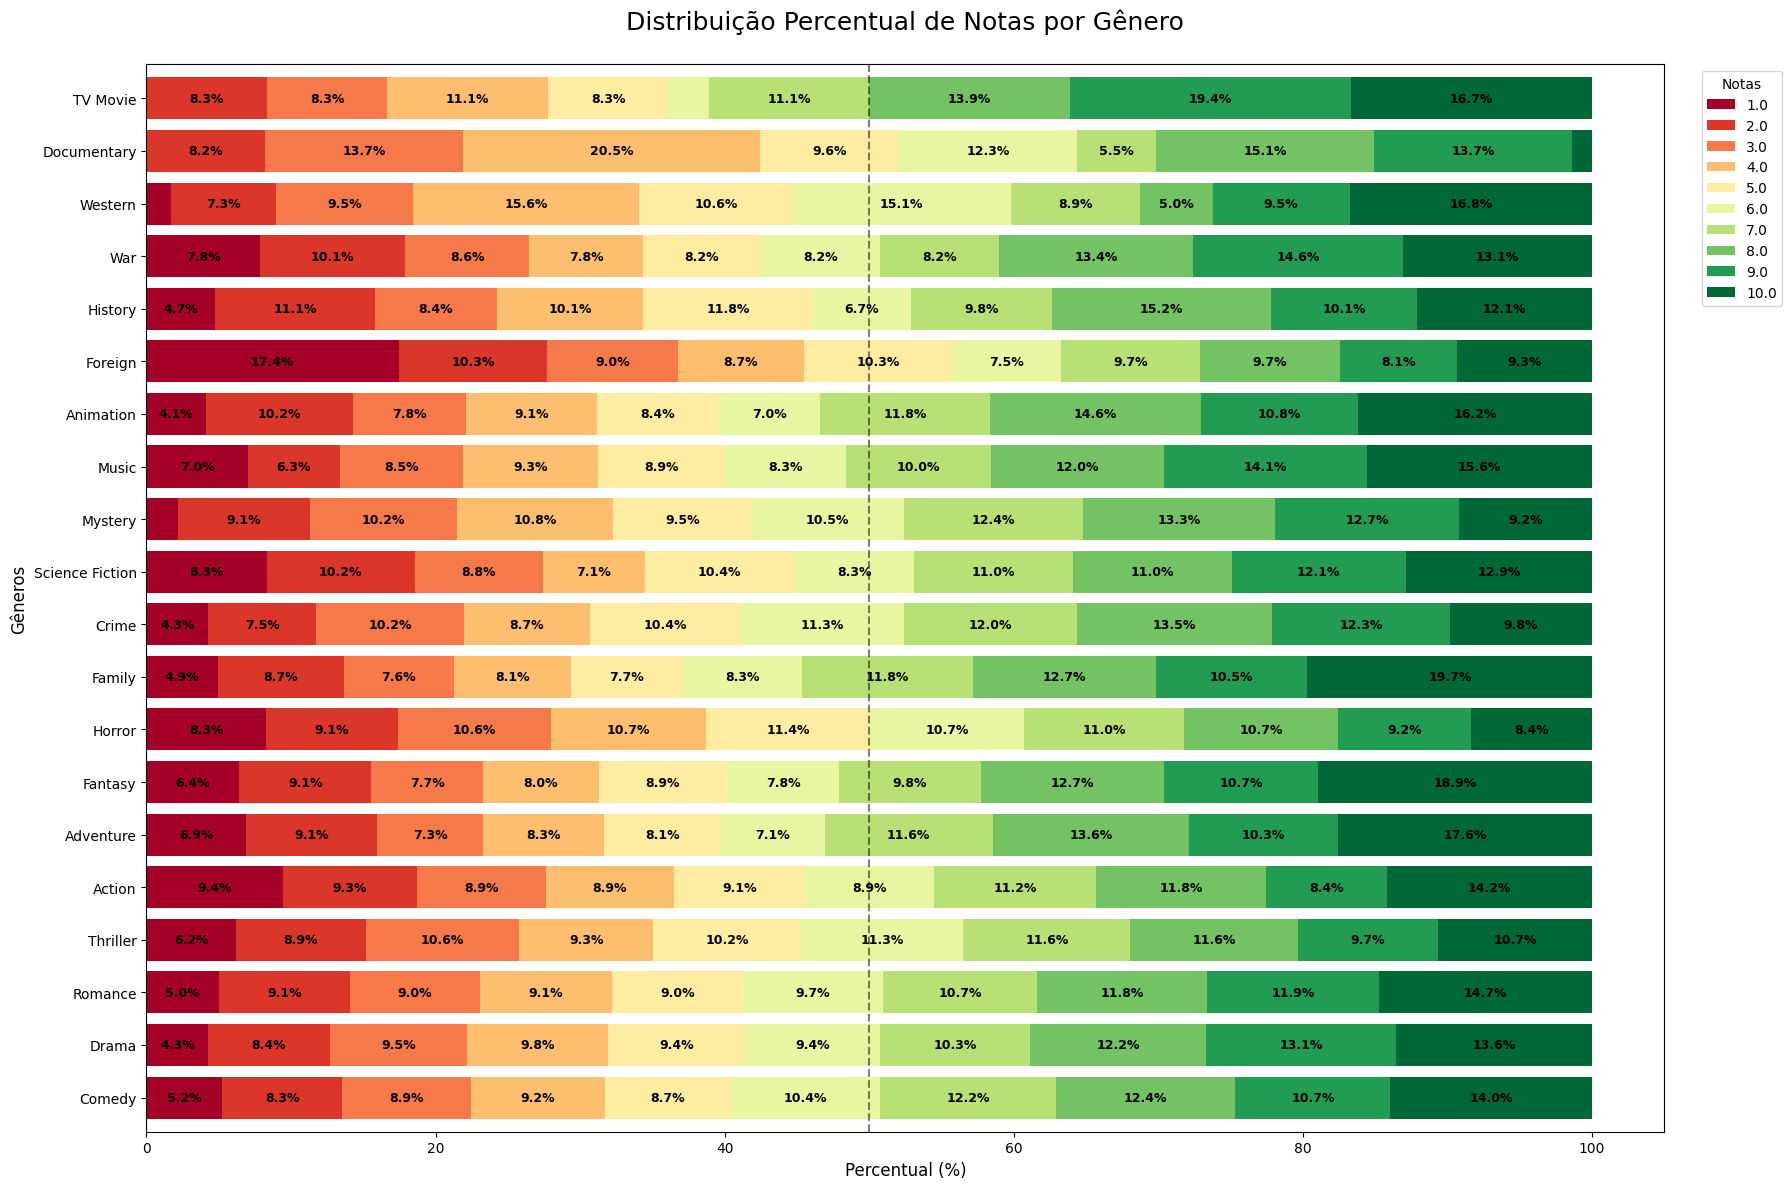

In [120]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparação e Crosstab (Percentual por Gênero)
df_gen = df_final.explode('genres').reset_index(drop=True)
tab_percent = pd.crosstab(df_gen['genres'], df_gen['Ratings'], normalize='index') * 100

# Ordenar pelos gêneros com mais avaliações para melhor visualização
ordem = df_gen['genres'].value_counts().index
tab_percent = tab_percent.reindex(ordem)

# 2. Plotagem
ax = tab_percent.plot(kind='barh', stacked=True, colormap='RdYlGn', figsize=(18, 12), width=0.8)

# 3. ADICIONANDO RÓTULOS DE DADOS EM CADA FATIA
for p in ax.patches:
    width = p.get_width()
    if width > 3.0:  # Só desenha o rótulo se a fatia tiver mais de 3% de largura
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(x, y, f'{width:.1f}%',
                ha='center', va='center',
                fontsize=9, color='black', fontweight='bold')

# 4. Ajustes Finais
plt.title('Distribuição Percentual de Notas por Gênero', fontsize=18, pad=25)
plt.xlabel('Percentual (%)', fontsize=12)
plt.ylabel('Gêneros', fontsize=12)
plt.legend(title='Notas', bbox_to_anchor=(1.02, 1), loc='upper left')

# Adiciona linha guia nos 50%
plt.axvline(50, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#Classificando Reviews com regressão logística

##Preparando a base de dados

In [134]:
import re
import sklearn
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import FuncFormatter

#Criaremos uma coluna na tabela chamada "Positivo/Negativo"
#As críticas que deram nota 6 ou superior serão consideradas positivas
#As críticas que deram nota inferior a 6 serão consideradas negativas
def positivoNegativo(rating):
    if rating>=6:
        return "Positivo"
    else:
        return "Negativo"

df_final['Positivo/Negativo'] = df_final["Ratings"].apply(positivoNegativo)


#Tratamento da base de dados (pré-processamento)
#Removeremos palavras comuns, como pronomes, artigos, verbos auxiliares, etc. com as "stop words"
#Converteremos todo o texto para letras minúsculas, dessa forma a mesma palavra não será contada de forma separada na vetorização caso apareça com letra maiúscula.
#Removeremos pontuação.
#O texto pré-processado será incluído em uma nova coluna que chamaremos de "review tratado"

stop_words = set(stopwords.words("english"))
stop_words.discard('no')
stop_words.discard('not')

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    palavras = texto.split()
    palavras = [p for p in palavras if p not in stop_words]
    return " ".join(palavras)

df_final["review tratado"] = df_final["Reviews"].apply(limpar_texto)

df_final.head()



,Ratings,Reviews,movie_name,Resenhas,genres,Positivo/Negativo,review tratado,Opinião prevista,Modelo Acertou
0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","[Comedy, Drama, Romance]",Negativo,laughs overall motivation characters incompreh...,Negativo,True
1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","[Comedy, Drama, Romance]",Negativo,waiting exhale waiting waiting waiting waiting...,Neutro,True
2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","[Comedy, Drama, Romance]",Negativo,angela basset good expected whitney no range a...,Neutro,True
3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","[Comedy, Drama, Romance]",Negativo,movie okay mediocre might even word describe s...,Neutro,True
4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"[Comedy, Drama, Romance]",Negativo,got opportunity see waiting exhale second time...,Positivo,False


##Modelo de Regresão Logística

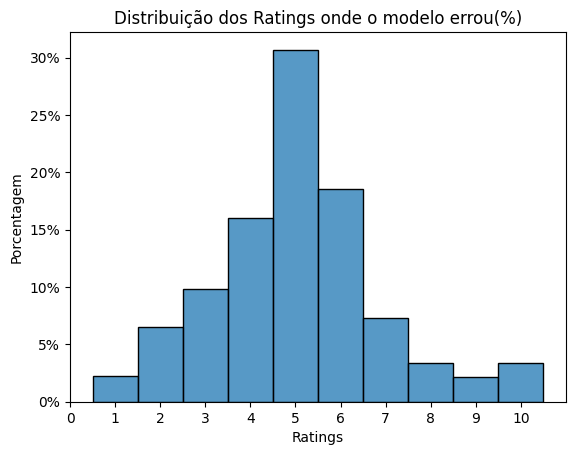

Ratings
1.0      2.2%
2.0      6.5%
3.0      9.8%
4.0     16.0%
5.0     30.7%
6.0     18.5%
7.0      7.3%
8.0      3.4%
9.0      2.2%
10.0     3.4%
Name: proportion, dtype: object


In [171]:
#Faremos a vetorização do texto, usando um vetor TF-IDF considerando o n-gram de até 2 palavras.
#Ou seja, faremos uma matriz para contar a repetição de palavras e sequências de 2 palavras.
#Aumentar o tamanho da matriz (features) melhora resultados, mas aumenta o tempo de processamento
#Aumentar o tamanho das expressões (n-gram) pode até aumentar a acurácia, mas aumenta o tamanho da matriz de forma exponencial.
vectorizer = TfidfVectorizer(max_features=20000,  ngram_range=(1,2))


#Usaremos um modelo de regressão que usará a matriz criada como variável independente e a coluna Positivo/Negativo como variável dependente
#A base de dados será dividida entre linhas usadas para treino e o restante para ter o modelo aplicado e posteriormente avaliado.
#80% da base será usada para treinar o modelo, e ele será aplicado sobre os 20% restantes.
X = vectorizer.fit_transform(df_final["review tratado"])
y = df_final["Positivo/Negativo"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)
predicao_opiniao = LogisticRegression(max_iter=1000)
predicao_opiniao.fit(X_train, y_train)
y_pred = predicao_opiniao.predict(X_test)



#Incluiremos no dataframe uma coluna com a opinião prevista pelo modelo.
#Incluiremos uma coluna dizendo se o modelo acertou ou não sua previsão.
df_final["Opinião prevista"] = predicao_opiniao.predict(X)
df_final["Modelo Acertou"] = df_final["Positivo/Negativo"] == df_final["Opinião prevista"]

#Fazendo um histograma para ilustrar a distribuição dos erros:
sns.histplot(erros["Ratings"], bins=range(12), stat="percent", discrete=True)
plt.xticks(range(11))
plt.title("Distribuição dos Ratings onde o modelo errou(%)")
plt.xlabel("Ratings")
plt.ylabel("Porcentagem")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.show()

#Analisando a distribuição dos erros:
percentuais = erros["Ratings"].value_counts(normalize=True).sort_index() * 100
percentuais_formatado = percentuais.map(lambda x: f"{x:.1f}%")
print(percentuais_formatado)



Conseguimos perceber que os erros estão majoritariamente na região de ratings de 4 a 6 (65,3%).
Esse erro faz muito sentido, pois nessa região intermediária a classificação binária (Positivo/Negativo) não representa as opiniões neutras.

##Medida de acurácia do modelo de regressão linear

In [172]:
#Para medir a acurácia que o modelo conseguiu, compararemos os positivos/negativos encontrados com os tabelados.
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acurácia: 0.8400621118012422
              precision    recall  f1-score   support

    Negativo       0.85      0.76      0.80      1654
    Positivo       0.83      0.90      0.87      2210

    accuracy                           0.84      3864
   macro avg       0.84      0.83      0.83      3864
weighted avg       0.84      0.84      0.84      3864



Significado:\
 -Precision:
 - Quando o modelo aponta que uma review é POSITIVA, ele acerta em 83% das vezes.
 - Quando o modelo aponta que uma review é NEGATIVA, ele acerta em 85% das vezes.

 -Recall:
 - O modelo acertou 90% das reviews POSITIVAS.
 - O modelo acertou 76% das reviews NEGATIVAS.

 Verificamos aqui que a maior dificuldade do modelo, por enquanto, é acertar quando a review é **NEGATIVA**.

##Amostra de reviews em que o modelo errou:

In [202]:
erros = df_final[df_final["Modelo Acertou"] == False]
amostra = erros.sample(5, random_state=2)

for i, row in enumerate(amostra.itertuples(), 1):
    print(f"\nReview {i}")
    print("Rating:", row.Ratings)
    print("Texto:", row.Reviews)




Review 1
Rating: 5.0
Texto: I rented this movie for my cousin, it was his pick and we watched it as soon as we got home, he loved it! I seriously was expecting this big travesty of a film with the way the users are talking about it on IMDb, but I have to honestly say that it wasn't THAT bad, come on, it's a kid's movie, what did you expect? Citizen Kane? For the kids it had a fun plot and cool visuals, yeah, the story was a little lame, but as adults we should know that this movie was not meant for us, so I am going to judge it on being a children's movie.These kids all have super powers, but don't know how to use them effectively, so the program of Zoom is going to help them become super heroes with a man who was a former celebrity type of hero who is now a has-been. They enjoy being kids with each other and learn how to use their powers in the right ways and must destroy Conor, another former super hero who went bad. Together they all must learn to a team and also a family.Like I sa

#Comparação com outros modelos de classificação

##Modelo de Naive-Bayes

In [173]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

print("Acurácia:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

Acurácia: 0.8170289855072463
              precision    recall  f1-score   support

    Negativo       0.87      0.67      0.76      1654
    Positivo       0.79      0.93      0.85      2210

    accuracy                           0.82      3864
   macro avg       0.83      0.80      0.81      3864
weighted avg       0.83      0.82      0.81      3864



##Modelo de Árvore de decisão

In [174]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("Acurácia:", accuracy_score(y_test, pred_dt))

Acurácia: 0.6586438923395446


##Comparação entre os modelos:

Coparando os valores de acurácia para os diferentes modelos, tivemos:\

Regressão logística: 0,84\
Naive-Bayes: 0,81\
Árvore de decisão: 0,66

#Classificação por regressão logística com 3 rótulos

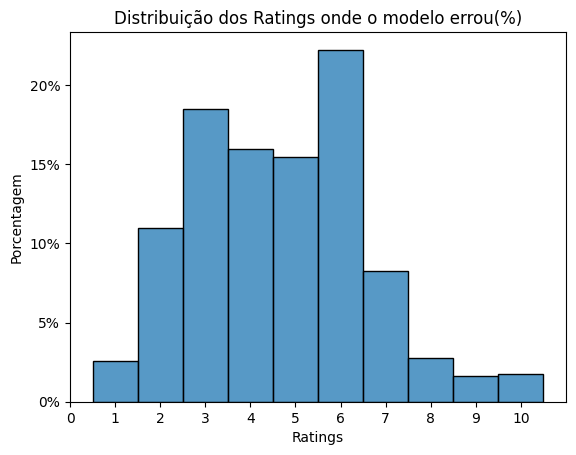

Ratings
1.0      2.6%
2.0     11.0%
3.0     18.5%
4.0     15.9%
5.0     15.5%
6.0     22.2%
7.0      8.2%
8.0      2.7%
9.0      1.6%
10.0     1.7%
Name: proportion, dtype: object


In [167]:
def positivoNegativoNeutro(rating):
    if rating>6:
        return "Positivo"
    elif rating<4:
        return "Negativo"
    else:
        return "Neutro"
vectorizer3 = TfidfVectorizer(max_features=20000,  ngram_range=(1,2))

df_final3=df_final.copy()

df_final3['Positivo/Negativo'] = df_final3["Ratings"].apply(positivoNegativoNeutro)

X3 = vectorizer3.fit_transform(df_final3["review tratado"])
y3 = df_final3["Positivo/Negativo"]
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=1
)
predicao_opiniao3 = LogisticRegression(max_iter=1000)
predicao_opiniao3.fit(X_train3, y_train3)
y_pred3 = predicao_opiniao3.predict(X_test3)


df_final3["Opinião prevista"] = predicao_opiniao3.predict(X3)
df_final3["Modelo Acertou"] = df_final3["Positivo/Negativo"] == df_final3["Opinião prevista"]
erros = df_final3[df_final3["Modelo Acertou"]==False]


#Fazendo um histograma para ilustrar a distribuição dos erros:
sns.histplot(erros["Ratings"], bins=range(12), stat="percent", discrete=True)
plt.xticks(range(11))
plt.title("Distribuição dos Ratings onde o modelo errou(%)")
plt.xlabel("Ratings")
plt.ylabel("Porcentagem")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.show()

#Analisando a distribuição dos erros:
percentuais = erros["Ratings"].value_counts(normalize=True).sort_index() * 100
percentuais_formatado = percentuais.map(lambda x: f"{x:.1f}%")
print(percentuais_formatado)

In [175]:
print("Acurácia:", accuracy_score(y_test3, y_pred3))
print(classification_report(y_test3, y_pred3))

Acurácia: 0.7153209109730849
              precision    recall  f1-score   support

    Negativo       0.72      0.64      0.67       922
      Neutro       0.59      0.48      0.53      1116
    Positivo       0.77      0.90      0.83      1826

    accuracy                           0.72      3864
   macro avg       0.69      0.67      0.68      3864
weighted avg       0.70      0.72      0.71      3864



Significado:\
 -Precision:
 - Quando o modelo aponta que uma review é POSITIVA, ele acerta em 77% das vezes.
 - Quando o modelo aponta que uma review é NEUTRA, ele acerta em 59% das vezes.
 - Quando o modelo aponta que uma review é NEGATIVA, ele acerta em 72% das vezes.

 -Recall:
 - O modelo acertou 90% das reviews POSITIVAS.
 - O modelo acertou 48% das reviews NEUTRA.
 - O modelo acertou 64% das reviews NEGATIVAS.

 Verificamos aqui que, ao adicionar um terceiro rótulo para clasificação:

* A precisão e recall para as reviews positivas praticamente não foi afetada.
* A precisão e recall para as reviews negativas caiu em cerca de 10% cada.
* A precisão e recall das reviews neutras fica em torno de 50%.

A aparente queda na precisão do modelo pode ser explicada devido ao aumento na complexidade, já que foi adicionado um terceiro rótulo para a classificação.